# Figure 5 — Detectors on a Euclid VIS frame, vs MER (inference)

Same style as the overlay in `io/06_detection_comparison.ipynb` (detectors on one VIS tile
at their selected thresholds), with the **Q1 MER catalogue added**: classical VIS
peak-finder, the foundation CenterNet head (fused bottleneck, `vis_peak` 200-tile), the
StemCenterNet head, and clean MER. Qualitative companion to the injection figure (Fig 6).

`REGEN` runs the detectors on the tile (GPU) and caches to `_fig5_overlay_cache.pkl`;
the plot cell loads it. Saves `paper/figures/fig5_detection.png`.

In [1]:
import sys, pickle
from pathlib import Path
import numpy as np

def find_repo_root(s=None):
    s=(s or Path.cwd()).resolve()
    for c in [s,*s.parents]:
        if (c/'models').exists() and (c/'data').exists(): return c
    raise FileNotFoundError('repo root')
REPO=find_repo_root(); NB=Path.cwd()
for p in [REPO/'models',REPO/'models'/'detection',REPO/'models'/'astrometry2']:
    if str(p) not in sys.path: sys.path.insert(0,str(p))
CACHE=NB/'_fig5_overlay_cache.pkl'
OUT=REPO/'paper'/'figures'/'fig5_detection.png'
MER_FITS=REPO/'data'/'edf_s_ood'/'catalogs_compact'/'mer_FINAL_q1_ECDFS_footprint.fits'
ENC=REPO/'models'/'checkpoints'/'jaisp_v10_q1_long'/'checkpoint_best.pt'
CN_CKPT=REPO/'checkpoints'/'q1_detection'/'centernet_vis_sep.pt'
ST_CKPT=REPO/'checkpoints'/'q1_detection'/'stem_mer.pt'
TILE='tile_x01792_y00000_tract5063_patch_25'
CN_CONF=0.30; ST_CONF=0.40; CLASSICAL_NSIG=3.0
REGEN = not CACHE.exists()
print('REGEN=',REGEN)

REGEN= True


In [2]:
if REGEN:
    import torch
    from astropy.table import Table
    from astropy.wcs import WCS
    from load_foundation import load_foundation
    from detection.centernet_detector import CenterNetDetector
    from detection.detector import JAISPEncoderWrapper
    from detection.stem_centernet_detector import StemCenterNetDetector
    from detection.dataset import _pseudo_labels_vis_sep
    from astrometry2.source_matching import safe_header_from_card_string
    DEV=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    def safe_rms(v):
        v=np.asarray(v,np.float32); g=np.isfinite(v)&(v>0)&(v<1e20)
        fb=float(np.sqrt(np.median(v[g]))) if g.any() else 1.0
        o=np.full(v.shape,fb,np.float32); o[g]=np.sqrt(v[g]); return o
    def t1(a): return torch.from_numpy(np.asarray(a,np.float32)[None,None]).to(DEV)
    r=np.load(REPO/'data'/'rubin_tiles_all'/f'{TILE}.npz',allow_pickle=True)
    e=np.load(REPO/'data'/'euclid_tiles_all_q1'/f'{TILE}_euclid.npz',allow_pickle=True)
    rimg=np.nan_to_num(np.asarray(r['img'],np.float32)); rrms=np.stack([safe_rms(v) for v in np.asarray(r['var'],np.float32)],0)
    vis=np.nan_to_num(np.asarray(e['img_VIS'],np.float32)); hw=vis.shape
    rb=['u','g','r','i','z','y']
    images={f'rubin_{b}':t1(rimg[k]) for k,b in enumerate(rb)}; rms={f'rubin_{b}':t1(rrms[k]) for k,b in enumerate(rb)}
    for b in ['VIS','Y','J','H']:
        images[f'euclid_{b}']=t1(np.nan_to_num(np.asarray(e[f'img_{b}'],np.float32))); rms[f'euclid_{b}']=t1(safe_rms(e[f'var_{b}']))
    foundation=load_foundation(str(ENC),device=DEV,freeze=True)
    enc=JAISPEncoderWrapper(foundation,freeze=True).to(DEV)
    cn=CenterNetDetector.load(str(CN_CKPT),encoder=enc,device=DEV).eval()
    st=StemCenterNetDetector.load(str(ST_CKPT),foundation,device=DEV).eval()
    def run(det,conf):
        with torch.no_grad():
            p=det.predict(images,rms,conf_threshold=conf,tile_hw=hw,nms_kernel=7,artifact_mask=None)
        return p['positions_px'].cpu().numpy().astype(np.float32)
    cn_xy=run(cn,CN_CONF); st_xy=run(st,ST_CONF)
    # classical VIS peak-finder
    cnorm,_,_,_=_pseudo_labels_vis_sep(vis,CLASSICAL_NSIG,1000)
    cl_xy=np.stack([cnorm[:,0]*(hw[1]-1),cnorm[:,1]*(hw[0]-1)],1).astype(np.float32) if len(cnorm) else np.zeros((0,2),np.float32)
    # MER clean -> px
    cat=Table.read(str(MER_FITS)); cl=(np.asarray(cat['vis_det'])==1)&(np.asarray(cat['spurious_flag'])!=1)
    w=WCS(safe_header_from_card_string(e['wcs_VIS'].item()))
    px,py=w.all_world2pix(np.asarray(cat['ra'],float)[cl],np.asarray(cat['dec'],float)[cl],0)
    m=np.isfinite(px)&np.isfinite(py)&(px>=0)&(px<hw[1])&(py>=0)&(py<hw[0])
    mer_xy=np.stack([px[m],py[m]],1).astype(np.float32)
    pickle.dump(dict(vis=vis.astype(np.float16),hw=hw,cl_xy=cl_xy,cn_xy=cn_xy,st_xy=st_xy,mer_xy=mer_xy,
                     tile=TILE,cn_conf=CN_CONF,st_conf=ST_CONF),open(CACHE,'wb'))
    print(f'classical={len(cl_xy)} CenterNet={len(cn_xy)} Stem={len(st_xy)} MER={len(mer_xy)}')
    del foundation,enc,cn,st
    if DEV.type=='cuda': torch.cuda.empty_cache()
else:
    print('REGEN skipped (cache present).')

JAISPFoundationV10: 9.2M trainable parameters
  stem_ch=64, hidden_ch=256, fused_scale=0.40"/px
  stream_depths={'rubin': 1, 'euclid': 2}
  rubin_concat=True  (symmetric concat fusion)
  loss_type=charbonnier  charbonnier_eps=0.001  core_l2_weight=0.2  core_info_thr=0.5
  rubin decoder channels: [128]
  euclid decoder channels: [256, 128]
Loaded v10 foundation (fused_scale=0.4, rubin_concat=True, loss=charbonnier, core_l2=0.2) from /home/shemmati/Work/Projects/JAISP/models/checkpoints/jaisp_v10_q1_long/checkpoint_best.pt


classical=212 CenterNet=216 Stem=257 MER=254


saved -> /home/shemmati/Work/Projects/JAISP/paper/figures/fig5_detection_r2.png


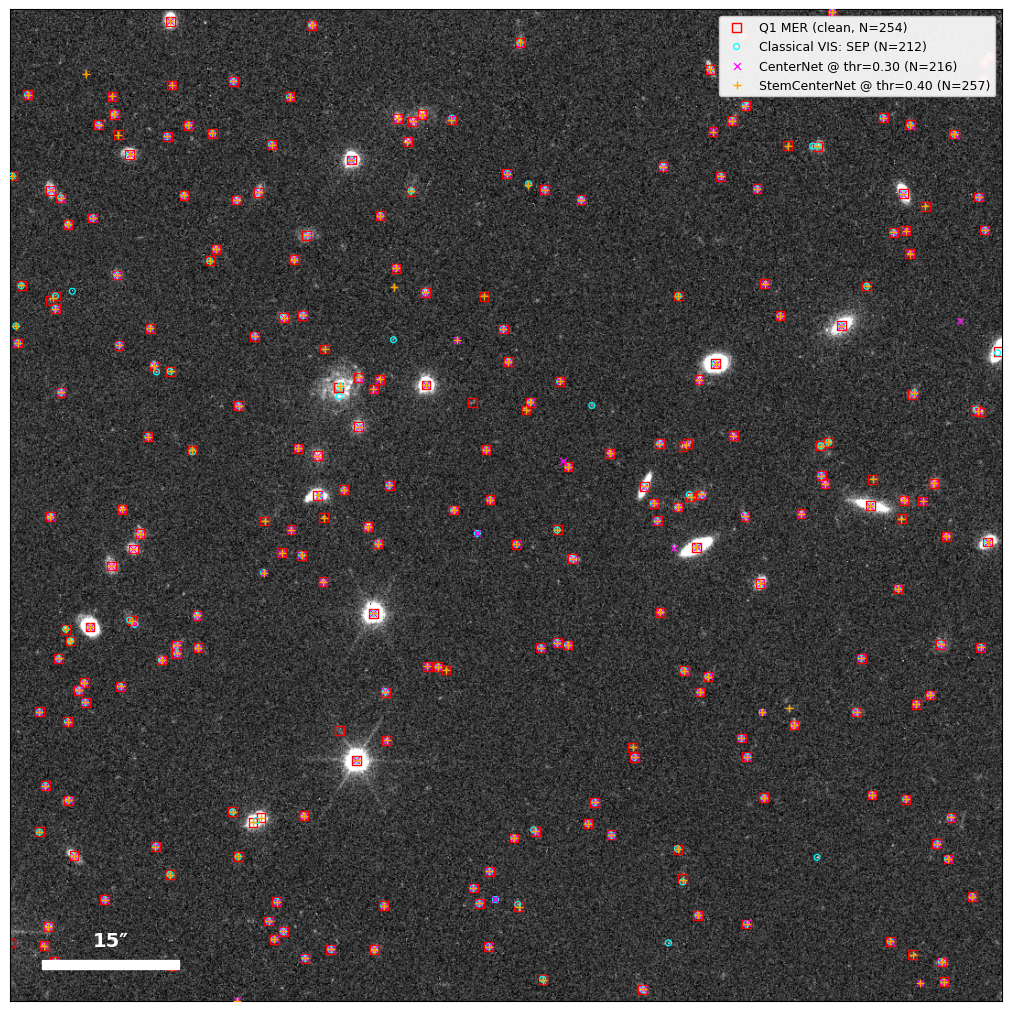

In [3]:
import pickle, numpy as np
import matplotlib.pyplot as plt

c=pickle.load(open(CACHE,'rb'))
vis=c['vis'].astype(np.float32); hw=c['hw']
def stretch_image(img,lo=1.0,hi=99.5):
    f=np.isfinite(img); a,b=np.percentile(img[f],[lo,hi]); b=max(b,a+1e-6)
    return np.clip((np.nan_to_num(img,nan=a)-a)/(b-a),0,1)

fig,ax=plt.subplots(1,1,figsize=(10,10),constrained_layout=True)
ax.imshow(stretch_image(vis),cmap='gray',origin='lower')
cl,cn,st,mer=c['cl_xy'],c['cn_xy'],c['st_xy'],c['mer_xy']
# z-order bottom->top: MER (below), SEP, CenterNet, Stem (on top)
if len(mer):
    ax.scatter(mer[:,0],mer[:,1],s=40,facecolors='none',edgecolors='red',linewidths=1.0,marker='s',zorder=2,
               label=f'Q1 MER (clean, N={len(mer)})')
if len(cl):
    ax.scatter(cl[:,0],cl[:,1],s=18,facecolors='none',edgecolors='cyan',linewidths=0.9,marker='o',zorder=3,
               label=f'Classical VIS: SEP (N={len(cl)})')
if len(cn):
    ax.scatter(cn[:,0],cn[:,1],s=24,c='magenta',marker='x',linewidths=0.9,zorder=4,
               label=f'CenterNet @ thr={c["cn_conf"]:.2f} (N={len(cn)})')
if len(st):
    ax.scatter(st[:,0],st[:,1],s=28,c='orange',marker='+',linewidths=1.0,zorder=5,
               label=f'StemCenterNet @ thr={c["st_conf"]:.2f} (N={len(st)})')
from matplotlib.patches import Rectangle
ax.set_xlim(0,hw[1]); ax.set_ylim(0,hw[0]); ax.set_xticks([]); ax.set_yticks([])
# 15" scale bar (VIS 0.1"/px -> 150 px)
barpx=15.0/0.1
ax.add_patch(Rectangle((35,35),barpx,10,facecolor='white',edgecolor='white',zorder=6))
ax.text(35+barpx/2,55,'15″',color='white',ha='center',va='bottom',fontsize=14,fontweight='bold',zorder=6)
lg=ax.legend(loc='upper right',fontsize=9,framealpha=0.92,facecolor='white')
for t in lg.get_texts(): t.set_color('black')
fig.savefig(OUT,dpi=300,bbox_inches='tight',facecolor='white'); print('saved ->',OUT)
plt.show()